<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [3]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [4]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [5]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('./airline_passengers.csv', parse_dates=['month'])
df.head()

,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [6]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df = df.set_index('month')
df = df.resample('MS').mean()
df.head()

,thousands_of_passengers
month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


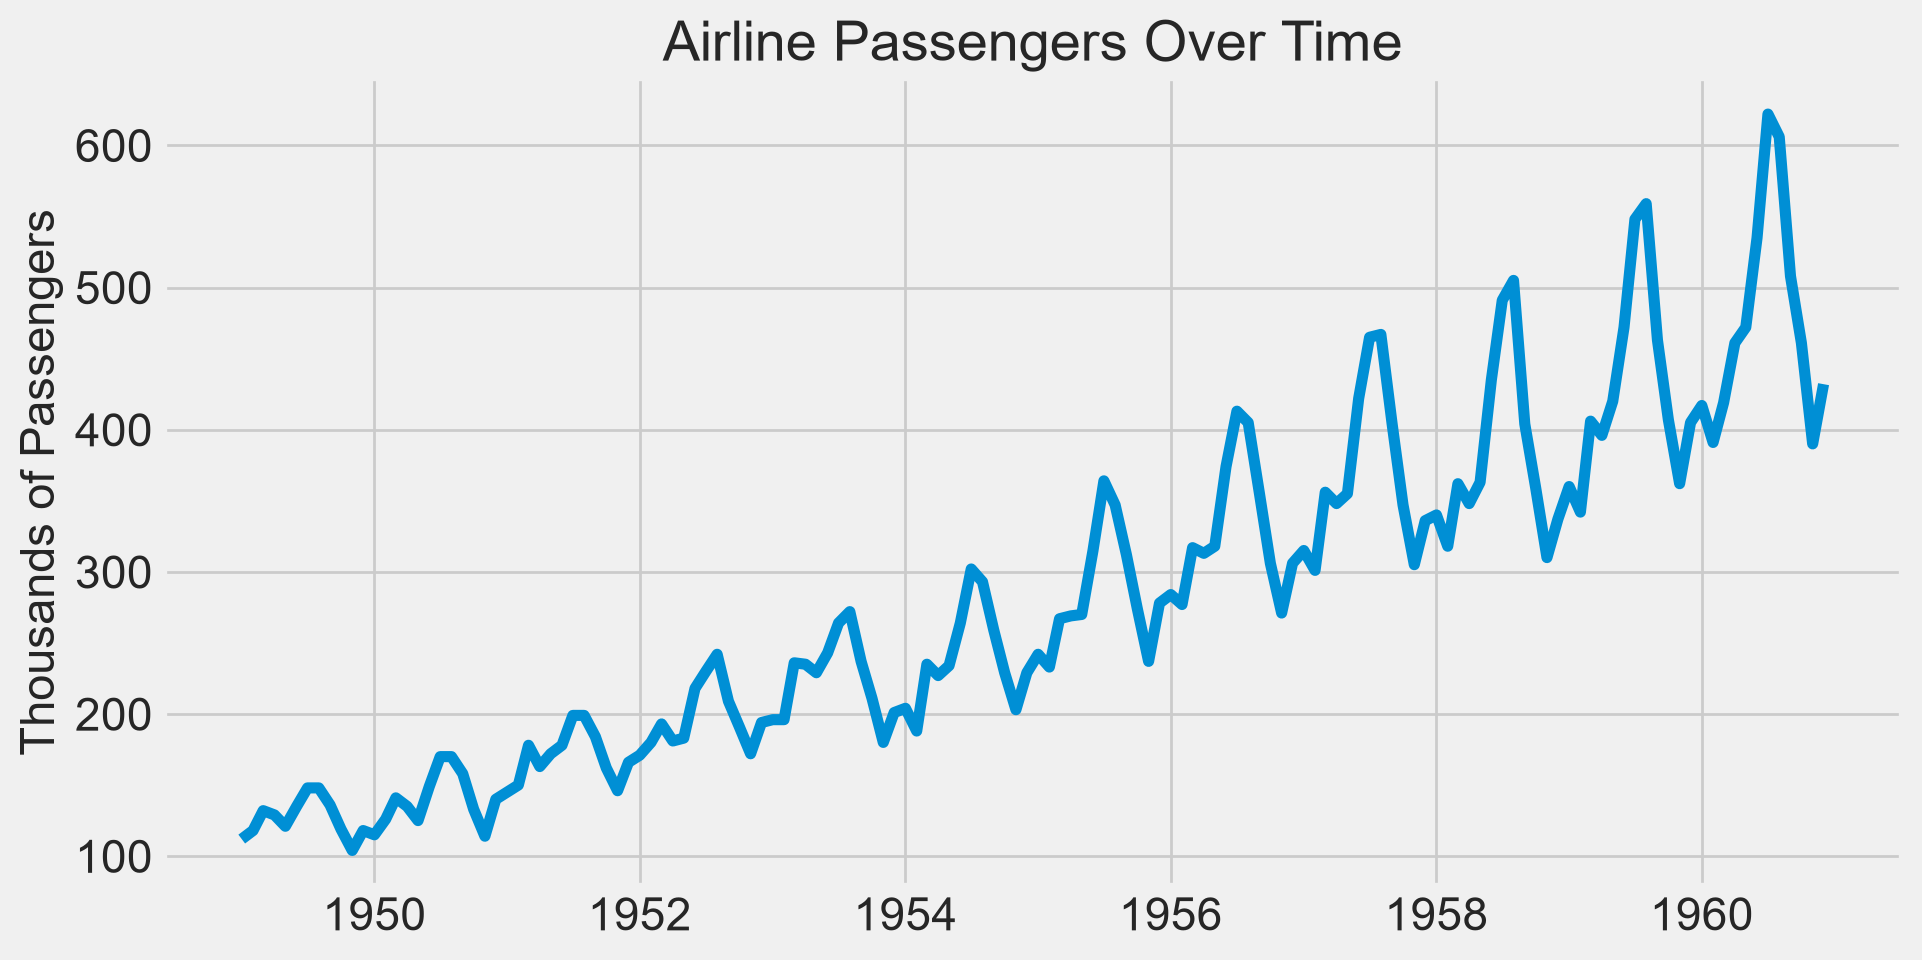

In [7]:
# 1c. Plot the full series and look at shape.
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df.index, df['thousands_of_passengers'])
plt.title('Airline Passengers Over Time')
plt.ylabel('Thousands of Passengers')
plt.grid(True)
plt.show()


---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [8]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'], title='raw series')

Augmented Dickey-Fuller Test: raw series
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [9]:
# Difference once and re-test
adf_test(df['thousands_of_passengers'].diff(), title='The First difference')

Augmented Dickey-Fuller Test: The First difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [10]:
# If needed, difference a second time and re-test
adf_test(df['thousands_of_passengers'].diff().diff(), title='The Second difference')

Augmented Dickey-Fuller Test: The Second difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d =  2`

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

(<Figure size 1200x400 with 2 Axes>,
 array([<Axes: title={'center': 'Autocorrelation'}>,
        <Axes: title={'center': 'Partial Autocorrelation'}>], dtype=object))

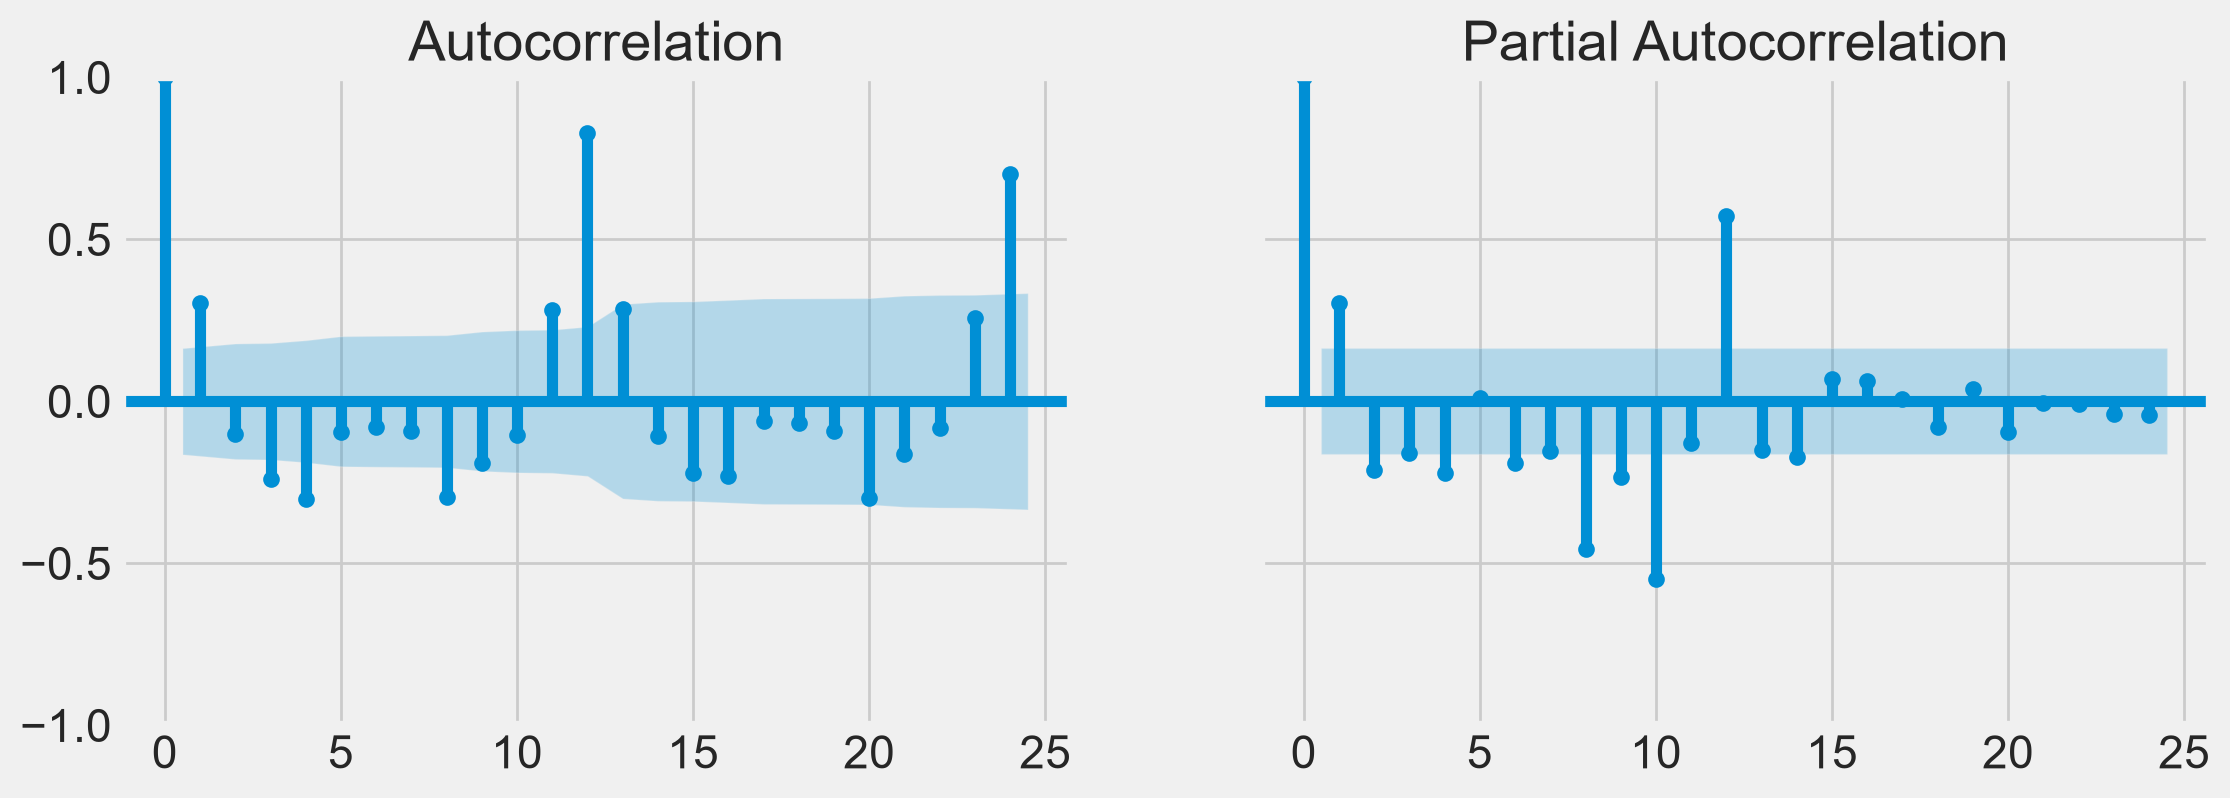

In [11]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['thousands_of_passengers'].diff().dropna(), lags=24)

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): 1
- q (MA terms): 1

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [12]:
# Run auto_arima with seasonal=False and print the summary
auto_model = auto_arima(df['thousands_of_passengers'], seasonal=False, trace=True,error_action='ignore')

auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.74 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.08 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.28 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.11 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.04 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(4, 1, 3)   Log Likelihood                -674.913
Date:                Wed, 19 Aug 2026   AIC                           1365.825
Time:                        09:19:36   BIC                           1389.528
Sample:                    01-01-1949   HQIC                          1375.457
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1727     85.616      8.458      0.000     556.369     891.976
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [13]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]

### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [14]:
# Fit ARIMA(p,d,q) on the training set
model= ARIMA(df_train['thousands_of_passengers'], order=(1,1,1))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(1, 1, 1)   Log Likelihood                -625.518
Date:                     Wed, 19 Aug 2026   AIC                           1257.035
Time:                             09:19:36   BIC                           1265.661
Sample:                         01-01-1949   HQIC                          1260.540
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5436      0.100     -5.443      0.000      -0.739      -0.348
ma.L1          0.9272      0.051     18.336      0.000       0.828       1.026
sigma2       816.5398     95.147      8.582      0.000     630.056    1003.024
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                 2.51
Prob(Q):                              0.57   Prob(JB):                         0.29
Heteroskedasticity (H):               6.76   Skew:                            -0.27
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.42
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A7. Predict on the test set

In [15]:
# Predict over the test period
predictions = model_fit.forecast(steps=12)
predictions

1960-01-01    433.451927
1960-02-01    417.984221
1960-03-01    426.393139
1960-04-01    421.821685
1960-05-01    424.306927
1960-06-01    422.955841
1960-07-01    423.690350
1960-08-01    423.291039
1960-09-01    423.508122
1960-10-01    423.390106
1960-11-01    423.454265
1960-12-01    423.419385
Freq: MS, Name: predicted_mean, dtype: float64

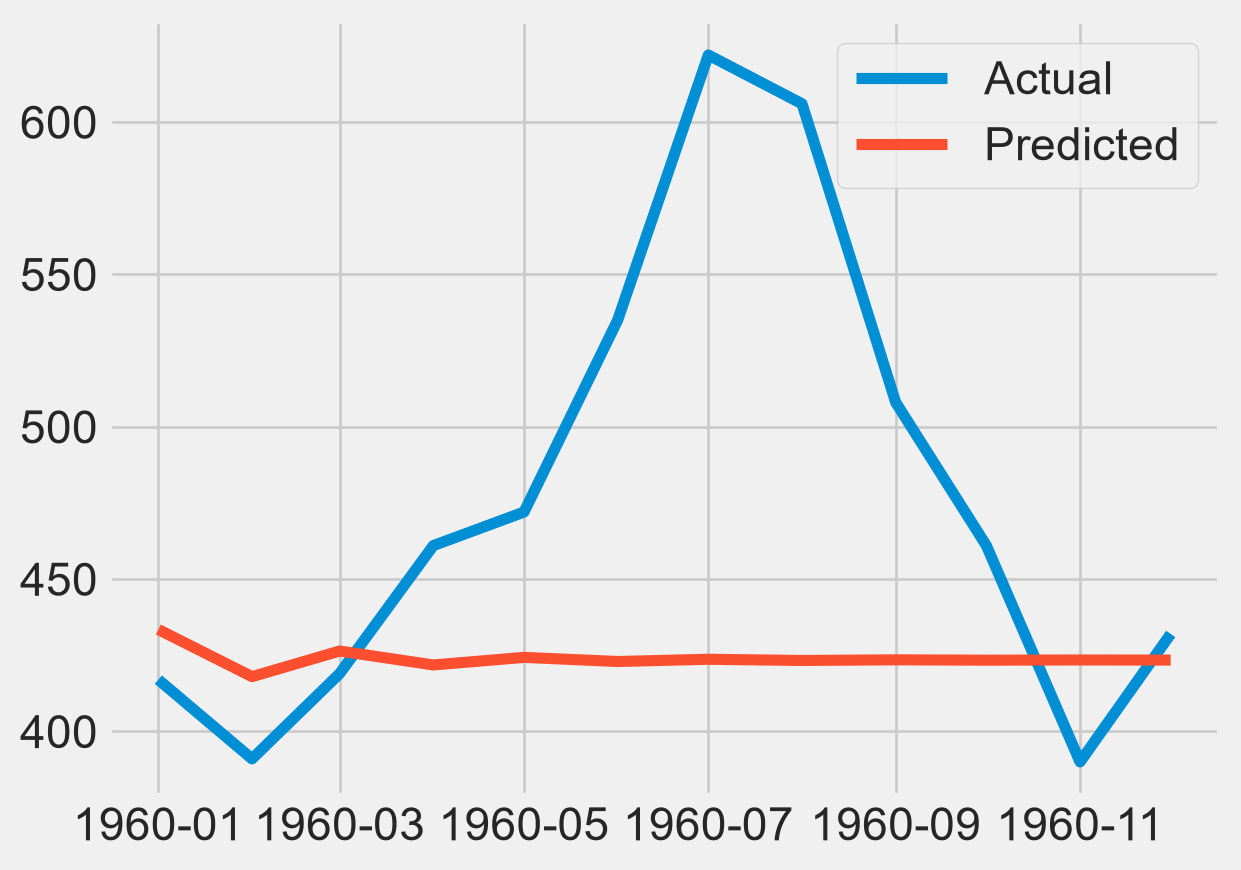

In [16]:
# Plot the test data vs predictions
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual')
plt.plot(df_test.index, predictions, label='Predicted')
plt.legend()
plt.show()

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [17]:
# Compute RMSE
from sklearn.metrics import root_mean_squared_error

error_arima = root_mean_squared_error(
    df_test['thousands_of_passengers'],
    predictions
)

print("ARIMA RMSE:", error_arima)
print("Mean:", df['thousands_of_passengers'].mean())

ARIMA RMSE: 91.22883941480012
Mean: 280.2986111111111


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

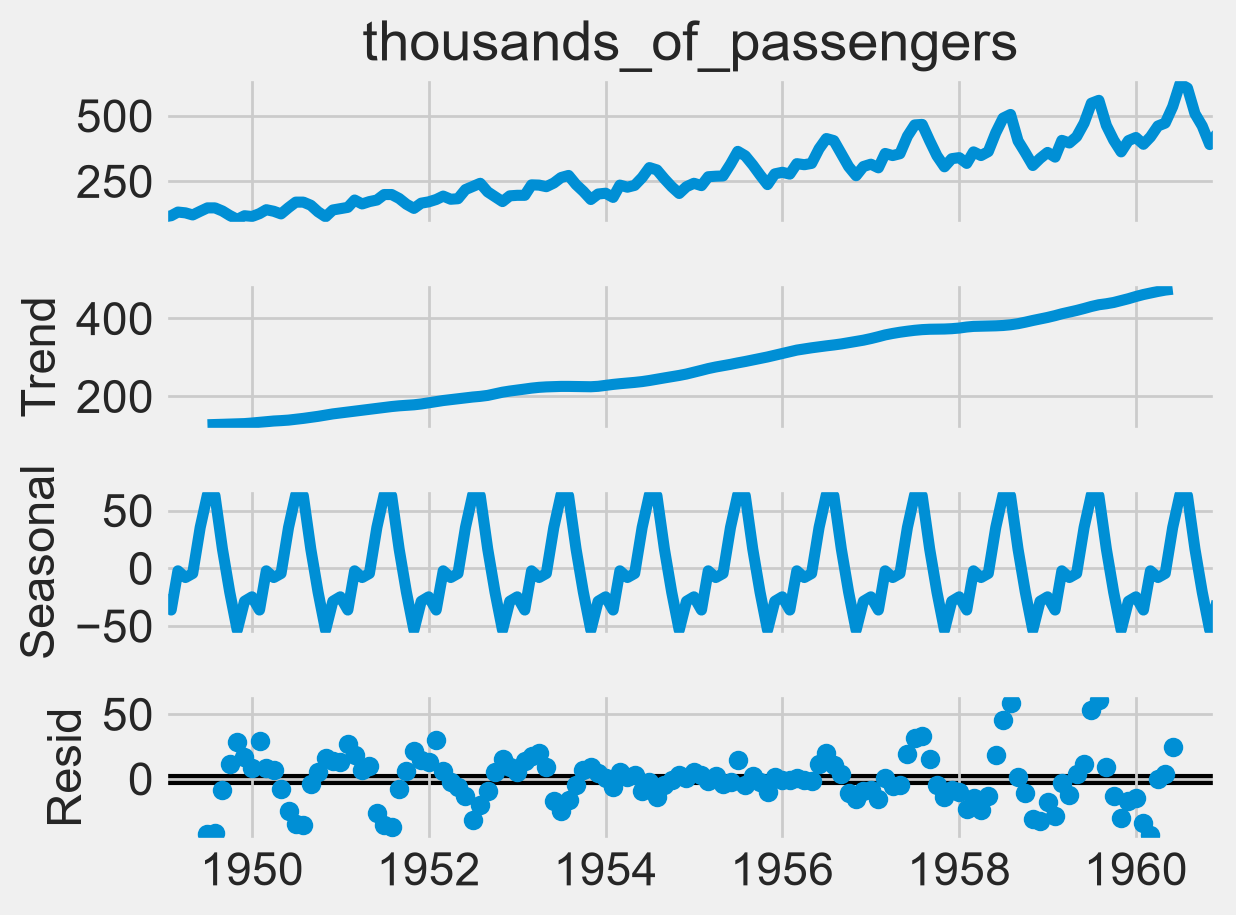

In [18]:
#YOUR CODE HERE 
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose( df['thousands_of_passengers'], period=12)

decomp.plot()
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [19]:
#YOUR CODE HERE

sarima_auto = auto_arima(
    df['thousands_of_passengers'],
    seasonal=True,
    m=12,
    trace=True, 
    error_action='ignore')

sarima_auto.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=1.28 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.19 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.68 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.22 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.68 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.13 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.21 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.62 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.59 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.29 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.08 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.10 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Wed, 19 Aug 2026   AIC                           1017.847
Time:                                     09:19:45   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3128     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = 
- seasonal_order (P,D,Q,m) = 

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [20]:
#YOUR CODE HERE
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    df_train['thousands_of_passengers'],
    order=(2, 1, 1),
    seasonal_order=(0, 1, 0, 12)
)

sarima_fit = sarima_model.fit()

sarima_fit.summary()

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Wed, 19 Aug 2026   AIC                            902.967
Time:                                     09:19:46   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5253      0.929     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      0.275      0.040      0.968      -0.529       0.551
ma.L1          0.3064      0.935      0.328      0.743      -1.527       2.140
sigma2       108.0094     13.498      8.002      0.000      81.553     134.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.97   Prob(JB):                         0.50
Heteroskedasticity (H):               1.47   Skew:                            -0.09
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

In [21]:
#YOUR CODE HERE
forecast_obj = sarima_fit.get_forecast(steps=12)

pred_sarima = forecast_obj.predicted_mean
confidence_int = forecast_obj.conf_int()

print(pred_sarima)
print(confidence_int)

1960-01-01    425.135147
1960-02-01    408.815435
1960-03-01    471.901435
1960-04-01    462.399947
1960-05-01    486.128077
1960-06-01    538.276346
1960-07-01    614.195485
1960-08-01    625.239583
1960-09-01    529.215533
1960-10-01    473.228649
1960-11-01    428.221496
1960-12-01    471.225397
Freq: MS, Name: predicted_mean, dtype: float64
            lower thousands_of_passengers  upper thousands_of_passengers
1960-01-01                     404.765722                     445.504572
1960-02-01                     382.968182                     434.662688
1960-03-01                     440.129496                     503.673373
1960-04-01                     426.327988                     498.471906
1960-05-01                     445.884942                     526.371211
1960-06-01                     494.422195                     582.130496
1960-07-01                     566.921724                     661.469245
1960-08-01                     574.820494                     675.658

### B5. Evaluate

In [22]:
# Compute RMSE

error_sarima = rmse(df_test['thousands_of_passengers'], pred_sarima)

print("SARIMA RMSE:", error_sarima)

SARIMA RMSE: 24.874106935502653


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

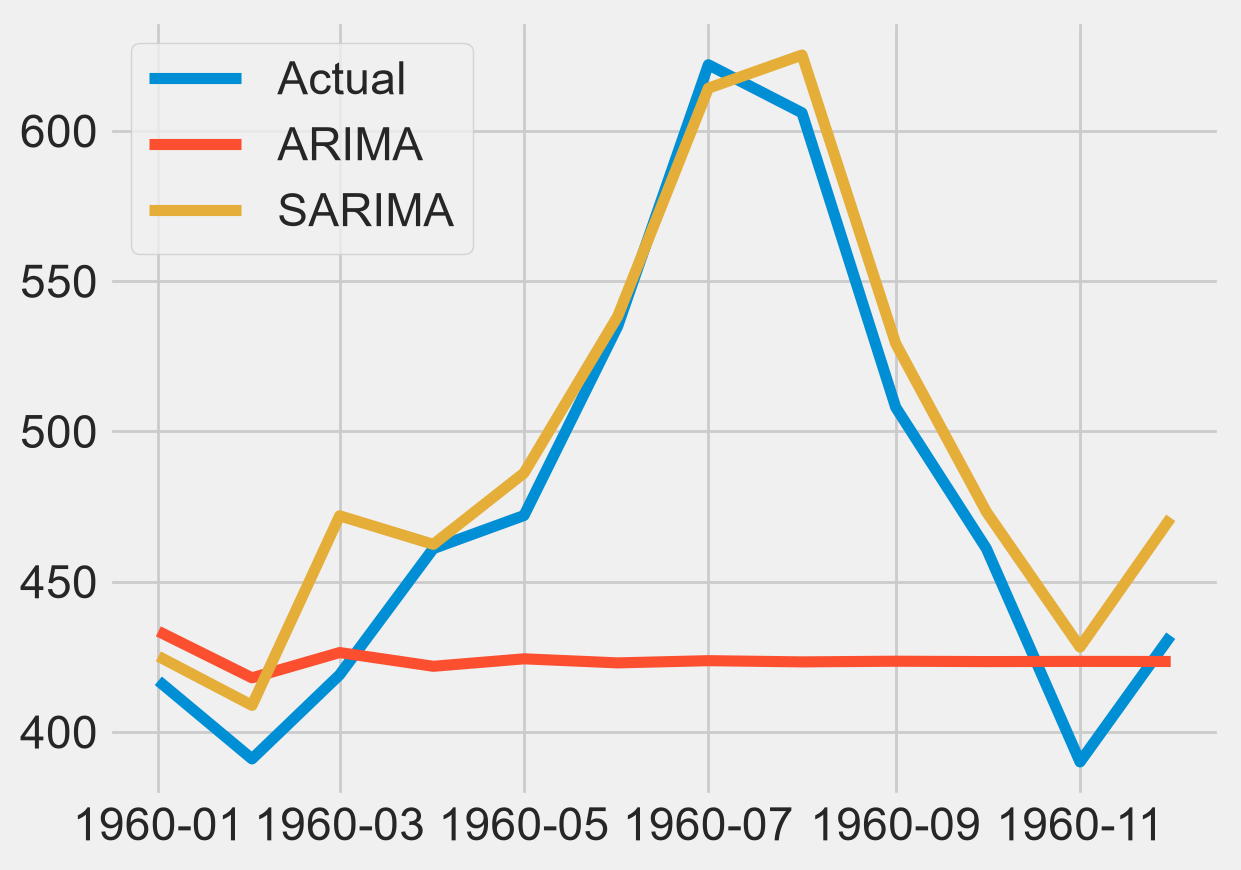

ARIMA RMSE: <function rmse at 0x000002A6FFF53E20>
SARIMA RMSE: 24.874106935502653


In [23]:
#YOUR CODE HERE
plt.plot(df_test.index, df_test['thousands_of_passengers'], label='Actual')
plt.plot(df_test.index, predictions, label='ARIMA')
plt.plot(df_test.index, pred_sarima, label='SARIMA')

plt.legend()
plt.show()

print("ARIMA RMSE:", rmse)
print("SARIMA RMSE:", error_sarima)

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

In [27]:
#YOUR CODE HERE
final_model = SARIMAX(
    df['thousands_of_passengers'],
    order=(2, 1, 1),
    seasonal_order=(0, 1, 0, 12)
)

final_fit = final_model.fit()

future_forecast = final_fit.get_forecast(steps=12)

future_pred = future_forecast.predicted_mean

print(future_pred)

1961-01-01    445.634926
1961-02-01    420.395003
1961-03-01    449.198319
1961-04-01    491.839939
1961-05-01    503.394459
1961-06-01    566.862422
1961-07-01    654.260136
1961-08-01    638.597436
1961-09-01    540.883678
1961-10-01    494.126547
1961-11-01    423.332624
1961-12-01    465.507482
Freq: MS, Name: predicted_mean, dtype: float64


## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
